<a href="https://colab.research.google.com/github/sn0wsally/self-study-Spatial-Transcriptomics/blob/main/breast_cancer_H%26E_image_load.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install scanpy
!pip install squidpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 666.0 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dask[array,data

In [5]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

In [6]:
# 1. 10x Genomics 유방암 ST 데이터 로드
print("🚀 데이터 로드 중... (시간이 조금 걸릴 수 있습니다)")
adata = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_1")
adata.var_names_make_unique()
library_id = "V1_Breast_Cancer_Block_A_Section_1"

🚀 데이터 로드 중... (시간이 조금 걸릴 수 있습니다)


/tmp/ipykernel_1480/668787451.py:3: FutureWarning: Use `squidpy.datasets.visium` instead.
  adata = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_1")


  0%|          | 0.00/9.50M [00:00<?, ?B/s]

  0%|          | 0.00/26.9M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
# 2. H&E 이미지 데이터 추출
# 공간 전사체 데이터에서 실제 이미지는 adata.uns 딕셔너리 깊은 곳에 저장되어 있습니다.
hires_image = adata.uns["spatial"][library_id]["images"]["hires"]
print(f"원본 고해상도 이미지 배열 형태: {hires_image.shape}")

원본 고해상도 이미지 배열 형태: (2000, 2000, 3)


In [8]:
# 3. Squidpy ImageContainer로 변환 (딥러닝 전처리 및 패치 추출용)
# 단순 Numpy 배열을 넘어, 좌표 기반 자르기(Crop)를 지원하는 객체로 만듭니다.
img = sq.im.ImageContainer(hires_image)

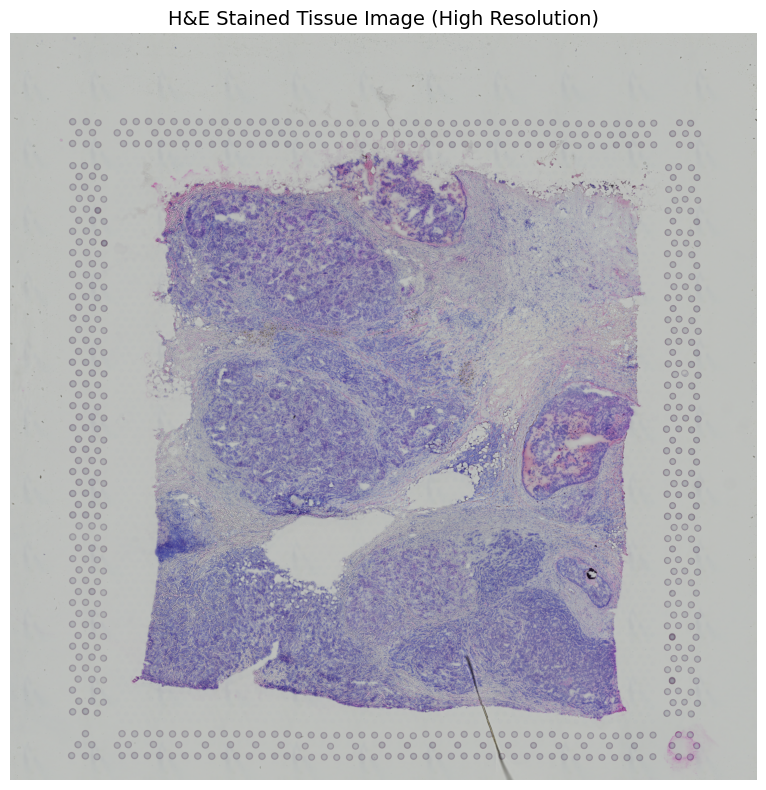

✅ ImageContainer 변환 완료: (2000, 2000)


In [9]:
# 4. H&E 원본 이미지 시각화
fig, ax = plt.subplots(figsize=(8, 8))
img.show(layer="image", ax=ax)
plt.title("H&E Stained Tissue Image (High Resolution)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"✅ ImageContainer 변환 완료: {img.shape}")